In [1]:
%load_ext autoreload
%autoreload 2

In [5]:
from utils import parse_evaluation_table

RESULTS_LATEX = '../example_results_table.txt'

df = parse_evaluation_table(RESULTS_LATEX)

In [9]:
df

,Project,Technique,File_P,File_R,File_F1,File_AUC,File_MCC,Class_P,Class_R,Class_F1,...,Method_P,Method_R,Method_F1,Method_AUC,Method_MCC,Block_P,Block_R,Block_F1,Block_AUC,Block_MCC
0,ANTLR4,LiteM,38.79,31.19,33.77,81.93,27.09,43.02,35.00,37.53,...,26.17,15.33,17.69,71.60,16.15,4.11,11.67,6.04,54.83,3.17
1,ANTLR4,LR,32.37,34.52,32.31,70.44,24.09,31.40,49.52,37.69,...,4.92,29.00,8.40,48.37,2.43,1.86,11.67,3.18,41.75,-1.03
2,DBeaver,LiteM,27.85,24.47,24.45,77.02,21.59,29.04,31.60,30.13,...,16.93,27.85,20.99,69.07,16.61,44.46,12.14,14.20,63.33,17.90
3,DBeaver,LR,20.55,50.34,29.10,74.76,26.64,20.40,42.40,27.50,...,7.69,47.51,13.22,63.67,8.84,10.75,18.38,9.41,51.96,5.12
4,Elasticsearch,LiteM,38.09,35.97,35.56,79.72,31.01,35.56,33.50,34.43,...,25.31,24.77,15.38,70.92,14.64,7.37,31.18,11.91,61.80,8.53
5,Elasticsearch,LR,29.78,35.23,32.14,74.61,26.21,37.57,21.84,27.55,...,6.85,51.04,12.07,65.43,9.80,5.58,22.03,8.90,53.85,4.28
6,ExoPlayer,LiteM,49.71,46.03,47.48,76.15,36.23,43.97,41.97,42.83,...,86.64,46.33,60.14,85.87,61.70,66.49,33.41,43.98,77.30,45.78
7,ExoPlayer,LR,48.70,47.52,45.91,74.36,34.92,39.69,50.87,44.51,...,9.53,55.12,16.24,64.48,10.99,10.25,51.21,17.04,70.60,18.03
8,FastJSON,LiteM,49.88,23.00,28.84,77.50,30.29,35.24,22.86,25.73,...,76.47,68.00,70.17,93.37,68.68,86.33,77.50,80.56,91.38,80.72
9,FastJSON,LR,10.66,25.67,14.07,62.04,10.79,16.50,49.76,24.28,...,20.80,80.09,32.84,83.41,30.82,30.77,67.50,40.71,86.16,42.34


In [6]:
import numpy as np
import pandas as pd
import scipy.stats as stats



def calculate_confidence_intervals(df, metric_col, confidence=0.95):
    """Calculates Mean, Standard Error, and Confidence Intervals

    grouped by Technique for a given metric.
    """
    results = []
    grouped = df.groupby("Technique")

    for tech_name, group in grouped:
        # Drop NaN values in the target column
        data = group[metric_col].dropna().values
        n = len(data)

        if n < 2:
            continue

        mean = np.mean(data)
        sem = stats.sem(data)  # Standard error of the mean

        # t-distribution critical value
        h = sem * stats.t.ppf((1 + confidence) / 2.0, n - 1)

        results.append(
            {
                "Technique": tech_name,
                "Sample Size (N)": n,
                "Mean": round(mean, 2),
                f"95% CI Lower": round(mean - h, 2),
                f"95% CI Upper": round(mean + h, 2),
                "Margin of Error": round(h, 2),
            }
        )

    return pd.DataFrame(results)



In [7]:
# --- Execution Example ---
if __name__ == "__main__":
    # Ensure "RQ3.txt" is in the same directory as your script
    try:

        # Select which metric you want to compute the CI for
        # Options: File_P, File_R, File_F1, File_AUC, File_MCC, Class_F1, etc.
        target_metric = "File_F1"

        ci_summary = calculate_confidence_intervals(df, target_metric)

        print(f"--- 95% Confidence Intervals for {target_metric} ---")
        print(ci_summary.to_string(index=False))

    except FileNotFoundError:
        print(
            "Error: Please make sure 'RQ3.txt' containing your LaTeX table is in this directory."
        )

--- 95% Confidence Intervals for File_F1 ---
Technique  Sample Size (N)  Mean  95% CI Lower  95% CI Upper  Margin of Error
       LR               18 31.70         25.16         38.25             6.54
    LiteM               18 39.11         31.74         46.48             7.37


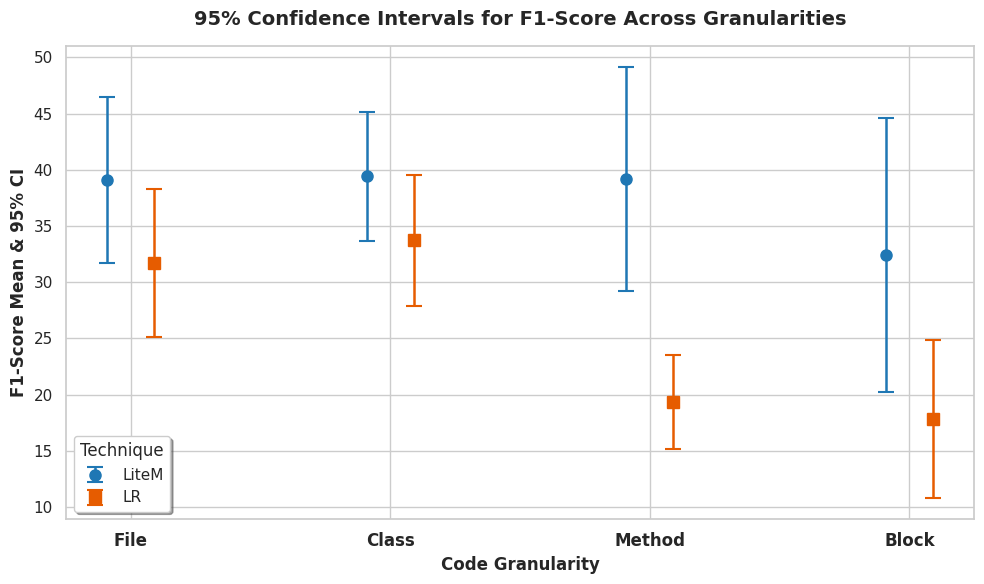

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


technique_colors = {
    # Cold color (Your main model)
    'LiteM': '#1f77b4',  # Deep Slate Blue (Stands out as the anchor)
    
    # Warm colors (The competitors)
    'RF': '#e65c00',     # Rich Orange (Warm and highly visible)
    'LR': '#cca300',     # Dark Mustard/Gold (Much easier to see than pure yellow)
    'XGB': '#b30000'     # Crimson Red (Deep and professional, not blinding)
}

# 1. Setup target metrics 
target_metrics = ["File_F1", "Class_F1", "Method_F1", "Block_F1"]
plot_data = []

# 2. Extract and format values from your existing function
for target_metric in target_metrics:
    # Get your CI summary dataframe
    ci_summary = calculate_confidence_intervals(df, target_metric)
    
    # Clean the metric name for a prettier x-axis label (e.g., "File_F1" -> "File")
    granularity = target_metric.split('_')[0]
    
    # Loop over each row (assuming columns like: Technique, Mean, Lower_95, Upper_95)
    for idx, row in ci_summary.iterrows():
        mean_val = row['Mean']
        lower_val = row['95% CI Lower']
        upper_val = row['95% CI Upper']
        
        plot_data.append({
            "Granularity": granularity,
            "Technique": row['Technique'],  # Change key if your column name differs
            "Mean": mean_val,
            "Error_Minus": mean_val - lower_val,
            "Error_Plus": upper_val - mean_val
        })

ci_plot_df = pd.DataFrame(plot_data)

# 3. Create the Error Bar Plot
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(10, 6))

# Group parameters
# # Transforma em lista
techniques = list(ci_plot_df["Technique"].unique())

# Pega do segundo elemento em diante e soma com o primeiro em uma lista
techniques = techniques[1:] + [techniques[0]]

granularities = [m.split('_')[0] for m in target_metrics]
x_coords = np.arange(len(granularities))
width = 0.18  # Spacing offset to separate the bars horizontally

# Custom markers/colors per technique
colors = [ "#1f77b4", "#e65c00", "#b30000", "#cca300",]
markers = ["o", "s", "^", "D"]

for i, tech in enumerate(techniques):
    tech_data = ci_plot_df[ci_plot_df["Technique"] == tech]
    
    # Ensure items follow the exact order of the granularities list
    means = [tech_data[tech_data["Granularity"] == g]["Mean"].values[0] for g in granularities]
    err_low = [tech_data[tech_data["Granularity"] == g]["Error_Minus"].values[0] for g in granularities]
    err_high = [tech_data[tech_data["Granularity"] == g]["Error_Plus"].values[0] for g in granularities]
    y_errors = [err_low, err_high]
    
    # Compute horizontal offset position
    pos = x_coords + (i - len(techniques)/2 + 0.5) * width
    
    ax.errorbar(pos, means, yerr=y_errors, fmt=markers[i % len(markers)], 
                color=colors[i % len(colors)], capsize=6, capthick=1.5, 
                elinewidth=1.8, ms=8, label=tech)

# Formatting axes
ax.set_xticks(x_coords)
ax.set_xticklabels(granularities, fontsize=12, fontweight='bold')
ax.set_ylabel("F1-Score Mean & 95% CI", fontsize=12, fontweight='bold')
ax.set_xlabel("Code Granularity", fontsize=12, fontweight='bold')
ax.set_title("95% Confidence Intervals for F1-Score Across Granularities", fontsize=14, fontweight='bold', pad=15)
ax.legend(title="Technique", fontsize=11, title_fontsize=12, frameon=True, shadow=True)

plt.tight_layout()
plt.savefig("f1_ci_comparison.png", dpi=300)
plt.show()